In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path

import json
import pandas as pd
import numpy as np

from utils import DATA_DIR
from download.weka import pull_predictions_from_weka

from dataloader import get_nd_array, get_slice

In [3]:
pull_predictions_from_weka("consistent_ranking")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_consistent_ranking_predictions.parquet


In [ ]:
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id', 'acc_per_char'] # load a subset of columns to save on memory

df = pd.read_parquet(f'{DATA_DIR}/all_consistent_ranking_predictions.parquet', columns=COLS)
print(f'Loaded {len(df):,} instance predictions')

In [5]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
SIZES  = df['size'].unique()
TOKEN_RATIO = df['token_ratio'].unique()

MMLU  = [t for t in TASKS if 'mmlu' in t]
TASKS = [t for t in TASKS if 'mmlu' not in t]
TASKS = sorted(TASKS)

### Significance Comparison

Explanation of a paired permutation test:


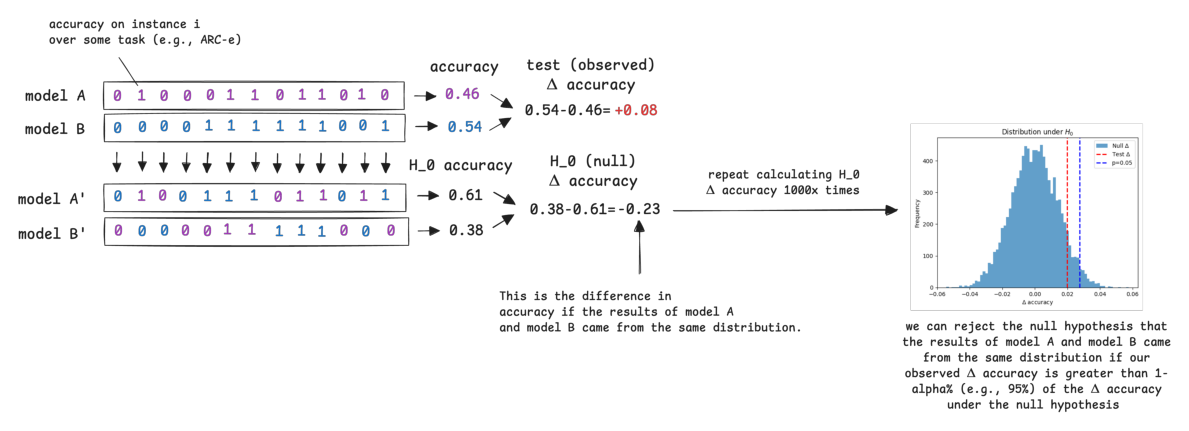

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def display_image(path, max_width=1200):
    img = Image.open(path)
    plt.figure(figsize=(min(max_width/100, img.width/100), img.height/100))
    plt.imshow(plt.imread(path))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print('Explanation of a paired permutation test:')
os.chdir('/Users/dhei/ai2/new-evals/analysis/notebooks')
display_image('assets/paired-permutation-test.png')

Example: Pairwise significance between mixes on OLMES at 1B (we want to predict the top cluster of mixes!)


Computing pairwise comparisons: 100%|██████████| 1/1 [00:08<00:00,  8.26s/it]


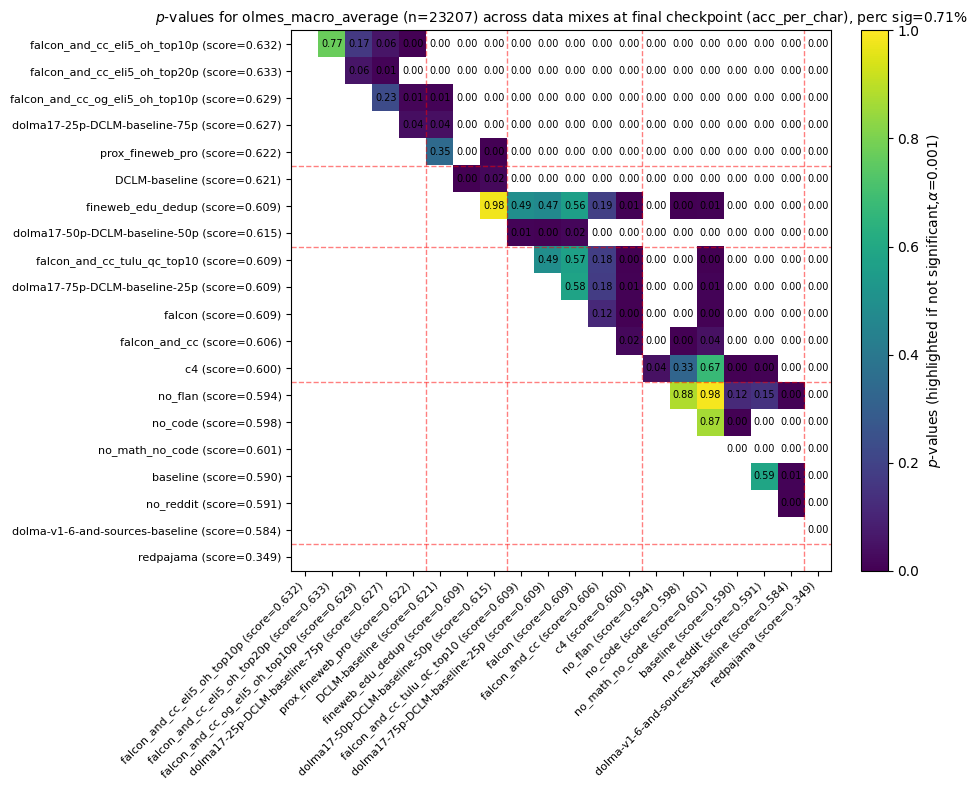

In [87]:
from stats import compute_significance

models = [model for model in MODELS if '1B' in model]
olmes  = [task for task in TASKS if ':para' not in task]

print('Example: Pairwise significance between mixes on OLMES at 1B (we want to predict the top cluster of mixes!)')
_, p_values, _ = compute_significance(
    df, 
    models=models, 
    metric='acc_per_char', 
    last_n=1,      # the "last n" checkpoints to average results
    alpha=0.001,   # significance level
    tasks=[olmes], # single tasks (e.g., hellaswag) or suites (e.g., OLMES)
    # tasks=[MMLU],
    # tasks=['arc_challenge'],
    do_plot=True
)

### Data Mix Selection

In [8]:
# Algorithm:
# Step 1: Run comparison at 150M scale
# Step 2: Get the models in the top significance cluster
# Step 3: Run comparison at next largest scale (e.g., 300M)
#         Repeat step 1
# Step 4: Compute P/R/F1 of whether the final mixes match the top signifiance cluster at target (1B) scale

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s]


Current size: 150M
Mixes remaining: ['falcon_and_cc_og_eli5_oh_top10p', 'fineweb_edu_dedup', 'falcon_and_cc_tulu_qc_top10', 'falcon_and_cc_eli5_oh_top10p', 'prox_fineweb_pro']



Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  2.32it/s]
/Users/dhei/ai2/new-evals/analysis/stats.py:192: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Current size: 300M
Mixes remaining: ['fineweb_edu_dedup', 'falcon_and_cc_eli5_oh_top10p']



Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  2.71it/s]
/Users/dhei/ai2/new-evals/analysis/stats.py:192: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Current size: 530M
Mixes remaining: ['fineweb_edu_dedup']


Predicted top mixes using mix selection: 
['fineweb_edu_dedup']

Top sig cluster at 1B scale: 
['fineweb_edu_dedup', 'falcon_and_cc_og_eli5_oh_top10p']

Compute used for mix selection: 1.98 * 10^21
Compute used if we trained all models at 1B scale: 2.59 * 10^22
P=1.00, R=0.50, F1=0.67


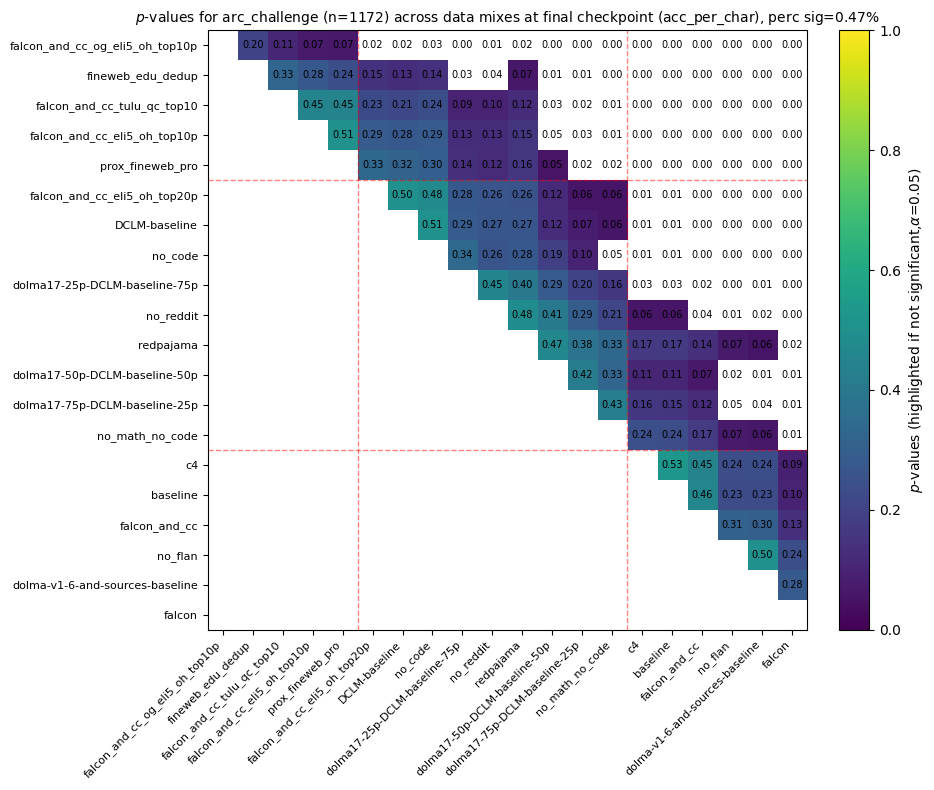

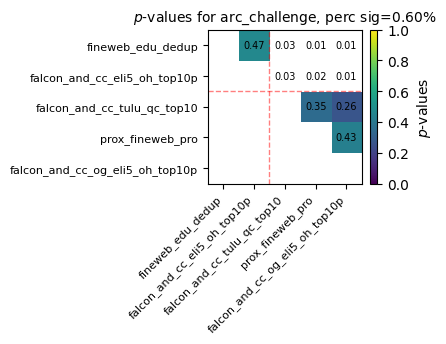

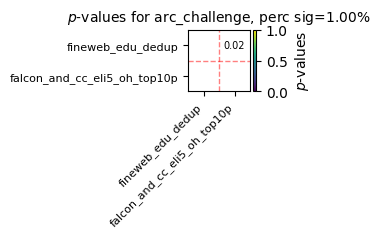

In [104]:
from stats import convert_sci, compute_f1
from mix_selection import simulate_mix_selection

top_n_clusters = 1 # How many significance clusters to keep for the next step
alpha = 0.05 # Significance level for cluster calculations
last_n = 1 # How many checkpoints up to the final checkpoint to average results

# SORTED_SIZES = ['150M'] 
SORTED_SIZES = ['150M', '300M', '530M']
# SORTED_SIZES = ['150M', '300M', '530M', '750M', '1B']

# task = olmes
task = 'arc_challenge'

gold_mixes, gold_compute = simulate_mix_selection(
    df,
    method='perc_sig', 
    sizes=['1B'], 
    models=MODELS,
    mixes=MIXES, 
    task=task, 
    mult=5, 
    top_n_clusters=top_n_clusters, 
    last_n=last_n,
    alpha=alpha
)

pred_mixes, pred_compute = simulate_mix_selection(
    df,
    method='perc_sig', 
    sizes=SORTED_SIZES, 
    models=MODELS,
    mixes=MIXES, 
    task=task, 
    mult=5, 
    top_n_clusters=top_n_clusters, 
    alpha=alpha,
    last_n=last_n,
    quiet=False
)

p, r, f1 = compute_f1(gold_mixes, pred_mixes)
print(f'\nPredicted top mixes using mix selection: \n{pred_mixes}\n')
print(f'Top sig cluster at 1B scale: \n{gold_mixes}\n')
print(f'Compute used for mix selection: {convert_sci(pred_compute)}')
print(f'Compute used if we trained all models at 1B scale: {convert_sci(gold_compute)}')
print(f'P={p:.2f}, R={r:.2f}, F1={f1:.2f}')

Running simulations for arc_challenge: 100%|██████████| 5/5 [00:09<00:00,  1.99s/it]


How to interpret: We want high *recall* scores (i.e., we want to minimize false negatives, where we would throw away a potentially good mix). High *precision* scores indicate less is used for selection:


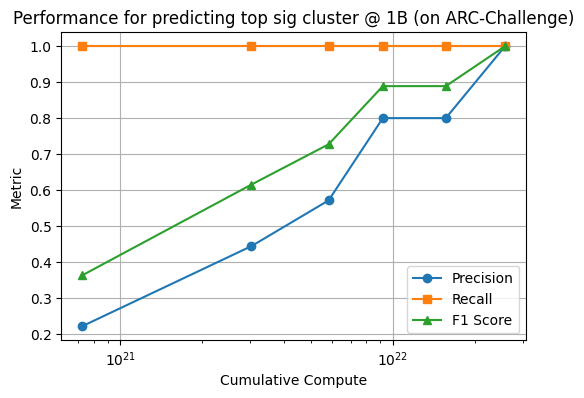

In [115]:
import matplotlib.pyplot as plt
from plot import plot_simulation_results
from mix_selection import run_simulations

SORTED_SIZES = ['150M', '300M', '530M', '750M', '1B']

results = run_simulations(
    df,
    task='arc_challenge',
    sorted_sizes=SORTED_SIZES,
    models=MODELS,
    mixes=MIXES,
    top_n_clusters=2, # How many significance clusters to keep for the next step
    top_n_clusters_eval=1, # How many significance clusters we want at the target scale
    alpha=0.001, # Significance level for cluster calculations
    last_n=20, # How many checkpoints up to the final checkpoint to average results
    model_pool='prefix', # (prefix, combination) Whether to test all combinations of mix orders
    quiet=True
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_title('Performance for predicting top sig cluster @ 1B (on ARC-Challenge)')
plot_simulation_results(results, ax)

print('How to interpret: We want high *recall* scores (i.e., we want to minimize false negatives, where we would throw away a potentially good mix). High *precision* scores indicate less is used for selection:')
plt.show()

Running simulations for arc_challenge: 100%|██████████| 5/5 [00:09<00:00,  2.00s/it]


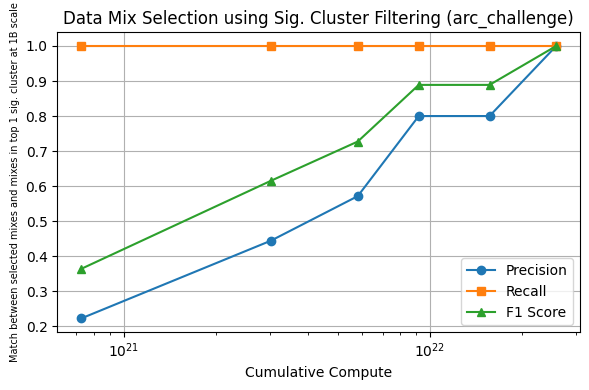

In [113]:
SORTED_SIZES = ['150M', '300M', '530M', '750M', '1B']
tasks = [task for task in TASKS if ':para' not in task]

tasks = tasks[:1]
# tasks = tasks
# tasks = [tasks]
# tasks = [olmes]
# tasks = [MMLU]

fig, axes = plt.subplots(len(tasks), 1, figsize=(6, 4*len(tasks)), sharex=True, sharey=True)

for i, task in enumerate(tasks):
    ax = axes[i] if len(tasks) > 1 else axes
    
    results = run_simulations(
        df,
        sorted_sizes=SORTED_SIZES,
        models=MODELS,
        mixes=MIXES,
        task=task,
        top_n_clusters=2, # How many significance clusters to keep for the next step
        top_n_clusters_eval=1, # How many significance clusters we want at the target scale
        alpha=0.001, # Significance level for cluster calculations
        last_n=20, # How many checkpoints up to the final checkpoint to average results
        model_pool='prefix', # How to select which sizes to test (prefix, combination)
    )
    
    plot_simulation_results(results, ax)
    task_name = task if not isinstance(task, list) else "OLMES Avg"
    ax.set_title(f"Data Mix Selection using Sig. Cluster Filtering ({task_name})")
    ax.set_ylabel(f"Match between selected mixes and mixes in top 1 sig. cluster at 1B scale", fontsize=7)
    
fig.tight_layout()
plt.show()

In [ ]:
# Ratio of compute vs. target scale method
6686214841600436633600 / 25867007688494284800000

0.2584842793615623

In [ ]:
# TODO: Ablations

# Can we keep the adjust the alpha?
# Can we adjust the top-n clusters for filtering?
# Can we adjust the top-n clusters for evaluation?

### Dev: Supporting more tasks

In [ ]:
from stats import compute_significance

# models = [model for model in MODELS if '300M' in model]
# models = [model for model in MODELS if '1B' in model]

# _, p_values, _ = compute_significance(df, models, 'acc_per_char', last_n=10, alpha=0.001, tasks=['arc_challenge'], do_plot=True)
# _, p_values, _ = compute_significance(df, models, 'acc_per_char', last_n=10, alpha=0.001, tasks=olmes, do_plot=True)

# _, _ = compute_significance(df, models, 'acc_per_char', tasks=['arc_easy', 'arc_challenge'], do_plot=True)
# _, _ = compute_significance(df, models, 'acc_per_char', last_n=10, alpha=0.001, tasks=['arc_easy', 'arc_challenge', 'csqa', 'boolq'], do_plot=True)
# _, _ = compute_significance(df, models, 'acc_per_char', last_n=10, alpha=0.001, tasks=['arc_easy', 'arc_challenge', 'csqa', 'boolq'], do_plot=True)

### Dev: Computing OLMES avg with MMLU

In [ ]:
# TODO: 
    # Create rejection simulator (i.e., a rule for rejecting mixes and a final score of the number of desired mixes remaining at 1B scale, along with the cumulative compute)
    # Calculate SPA (we can interpret whether we "trust" the stat sig results by looking at SPA and the rejection metric)

In [ ]:
# Dev: Adding support for OLMES AVG and MMLU

models = [model for model in MODELS if '1B' in model]

mixes, scores = get_nd_array(df, ['mix', 'step'], 'acc_per_char', model=models, task=['arc_challenge', 'arc_easy'], step='max')

In [ ]:
from stats import create_stratified_array
from utils.pce import compute_weighted_pairwise_p_values

models = [model for model in MODELS if '1B' in model]

mixes, scores = get_nd_array(df, ['mix', 'step'], 'acc_per_char', model=models, task=['arc_challenge', 'arc_easy'], step='max')

# # compute unweighted p-values
# p_values = compute_pairwise_p_values(scores)
# p_values[2, 3]

# compute weighted p-values
slices = get_slice(df, model=models, task=['arc_challenge', 'arc_easy'])
unique_counts = slices.groupby('task')['native_id'].nunique()
scores = scores[:, 0, :]
weights = create_stratified_array(unique_counts)
p_values = compute_weighted_pairwise_p_values(scores, weights=weights)

p_values[2, 3]

0.017

In [ ]:
np.unique(weights, return_counts=True)

(array([ 500., 1172., 1221., 1267., 1838., 1954., 2376., 3270.]),
 array([ 500, 1172, 1221, 1267, 1838, 1954, 2376, 3270]))

In [ ]:
mmlu = [task for task in MMLU+TASKS if ':para' not in task and 'hellaswag' not in task]

mixes, scores = get_nd_array(df, 'mix', 'acc_per_char', model=models, task=mmlu, step='max', sorted=True)
slices = get_slice(df, model=models, task=mmlu)
unique_counts = slices.groupby('task')['native_id'].nunique() # new
weights = create_stratified_array(unique_counts) # new

In [ ]:
weights

array([1172., 1172., 1172., ..., 1267., 1267., 1267.])

In [ ]:
weights.sum()

34839244.0

In [ ]:
unique_counts

task
arc_challenge            1172
arc_easy                 2376
boolq                    3270
csqa                     1221
mmlu_abstract_algebra     100
                         ... 
mmlu_world_religions      171
openbookqa                500
piqa                     1838
socialiqa                1954
winogrande               1267
Name: native_id, Length: 65, dtype: int64

<Axes: >

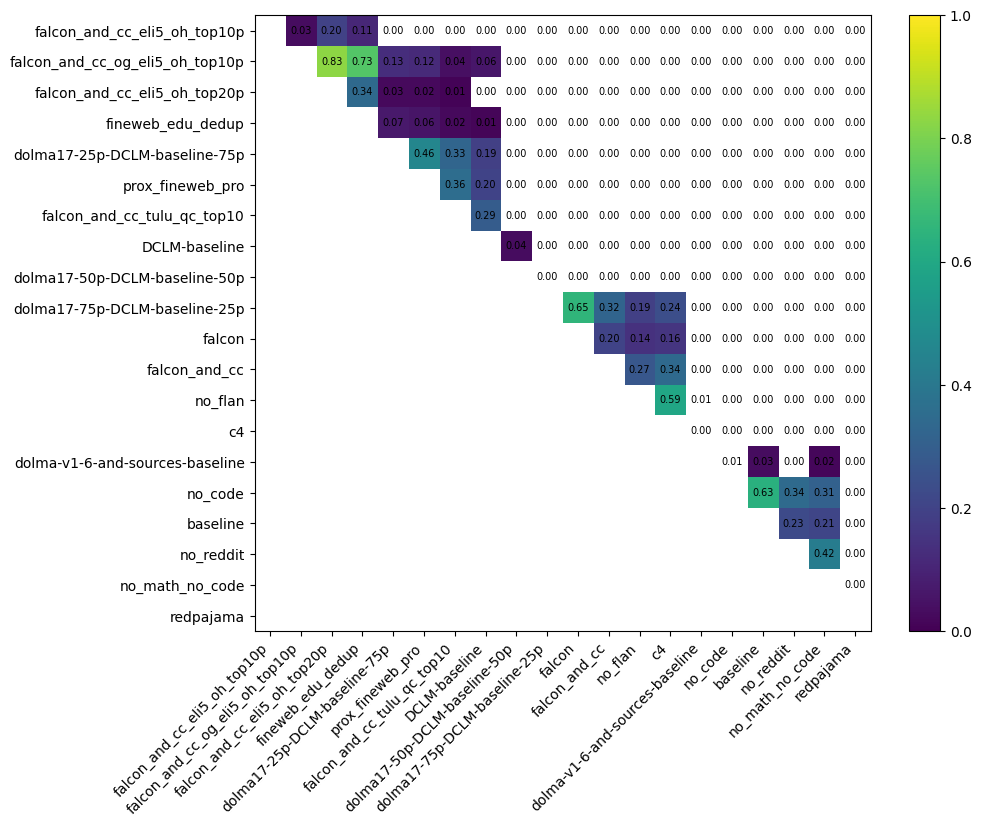

In [ ]:
import matplotlib.pyplot as plt
from plot import plot_heatmap

models = [model for model in MODELS if '1B' in model]
olmes = [task for task in TASKS if ':para' not in task and 'hellaswag' not in task]

mixes, scores = get_nd_array(df, 'mix', 'acc_per_char', model=models, task=olmes, step='max', sorted=True)
slices = get_slice(df, model=models, task=olmes)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax = plot_heatmap(ax, p_values, mixes, alpha=0.01)

### Dev: Fixing missing data @ 150M

In [ ]:
# Problem: Missing some evals for early checkpoints of 150M

curr_size = '150M'

curr_mixes = MIXES
curr_models = [model for model in MODELS if (curr_size in model) and any(mix in model for mix in curr_mixes)]

get_nd_array(df, ['mix', 'step'], 'acc_per_char', model=curr_models, task='arc_easy')

# pred_mixes, pred_compute = simulate_mix_selection('perc_sig', ['1B'], MIXES, 'arc_easy', top_n_clusters=top_n_clusters, alpha=alpha)

(2376, 179)


ValueError: cannot reshape array of size 425304 into shape (2376,20,9)